In [2]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
ias15_archive = rebound.Simulationarchive("../examples/embryo_ias15/embryo_ias15_8")

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)


In [4]:
trace_archive = rebound.Simulationarchive("../examples/embryo_trace/embryo_trace_8")

In [5]:
trace_famtree = pd.read_csv(
    "../examples/embryo_trace/famtree_8_trace.csv",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

erosive_trace = trace_famtree[(trace_famtree['type'] == 4) | (trace_famtree['type'] == 5) | (trace_famtree['type'] == 6) | (trace_famtree['type'] == 8)
                              | (trace_famtree['type'] == 11)]

In [6]:
ias15_famtree = pd.read_csv(
    "../examples/embryo_ias15/famtree_8_ias15.csv",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

erosive_ias15 = ias15_famtree[(ias15_famtree['type'] == 4) | (ias15_famtree['type'] == 5) | (ias15_famtree['type'] == 6) | (ias15_famtree['type'] == 8)
                              | (ias15_famtree['type'] == 11)]

In [7]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [8]:
ias15_times = []
ias15_n_bodies = []
ias15_masses = []
ias15_mass_errors = []
ias15_angular_momentums = []
ias15_L_rel_errors = []

for i in range(len(ias15_archive)):
    snap = ias15_archive[i]
    ias15_times.append(snap.t)
    ias15_n_bodies.append(snap.N)

    Lx, Ly, Lz = snap.angular_momentum()
    ias15_angular_momentums.append(get_abs(Lx, Ly, Lz))

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    ias15_masses.append(m)

for i in range(len(ias15_masses)):
    diff = np.abs((ias15_masses[i] - ias15_masses[0]))
    rel_diff = diff/np.abs(ias15_masses[0])
    ias15_mass_errors.append(rel_diff)

for i in range(len(ias15_angular_momentums)):
    diff = np.abs(ias15_angular_momentums[i] - ias15_angular_momentums[0])
    ias15_L_rel_errors.append(diff/np.abs(ias15_angular_momentums[0]))

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [9]:
ias15_dict = {
    't': ias15_times,
    'N_Bodies': ias15_n_bodies,
    'total_masses': ias15_masses,
    'm_errors': ias15_mass_errors,
    'angular_momentums': ias15_angular_momentums,
    'L_rel_errors': ias15_L_rel_errors
}

ias15_archive_df = pd.DataFrame(ias15_dict)

ias15_archive_df.head()

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors
0,0.000000,31,1.000009,0.0,0.00003,0.000000e+00
1,10.000459,31,1.000009,0.0,0.00003,3.440551e-16
2,20.000112,31,1.000009,0.0,0.00003,1.146850e-16
3,30.000448,31,1.000009,0.0,0.00003,1.146850e-16
4,40.000266,31,1.000009,0.0,0.00003,1.146850e-16


In [10]:
trace_times = []
trace_n_bodies = []
trace_masses = []
trace_mass_errors = []
trace_angular_momentums = []
trace_L_rel_errors = []

for i in range(len(trace_archive)):
    snap = trace_archive[i]
    trace_times.append(snap.t)
    trace_n_bodies.append(snap.N)

    Lx, Ly, Lz = snap.angular_momentum()
    trace_angular_momentums.append(get_abs(Lx, Ly, Lz))

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    trace_masses.append(m)

for i in range(len(trace_masses)):
    diff = np.abs((trace_masses[i] - trace_masses[0]))
    rel_diff = diff/np.abs(trace_masses[0])
    trace_mass_errors.append(rel_diff)

for i in range(len(trace_angular_momentums)):
    diff = np.abs(trace_angular_momentums[i] - trace_angular_momentums[0])
    trace_L_rel_errors.append(diff/np.abs(trace_angular_momentums[0]))

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [11]:
trace_dict = {
    't': trace_times,
    'N_Bodies': trace_n_bodies,
    'total_masses': trace_masses,
    'm_errors': trace_mass_errors,
    'angular_momentums': trace_angular_momentums,
    'L_rel_errors': trace_L_rel_errors
}

trace_archive_df = pd.DataFrame(trace_dict)

trace_archive_df.head()

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors
0,0.000000,31,1.000009,0.0,0.00003,0.000000e+00
1,10.010959,31,1.000009,0.0,0.00003,8.490248e-12
2,20.005479,31,1.000009,0.0,0.00003,1.631372e-11
3,30.016438,31,1.000009,0.0,0.00003,2.318198e-11
4,40.010959,31,1.000009,0.0,0.00003,3.167268e-11


Text(0.5, 0.98, 'TRACE and IAS15, run 8')

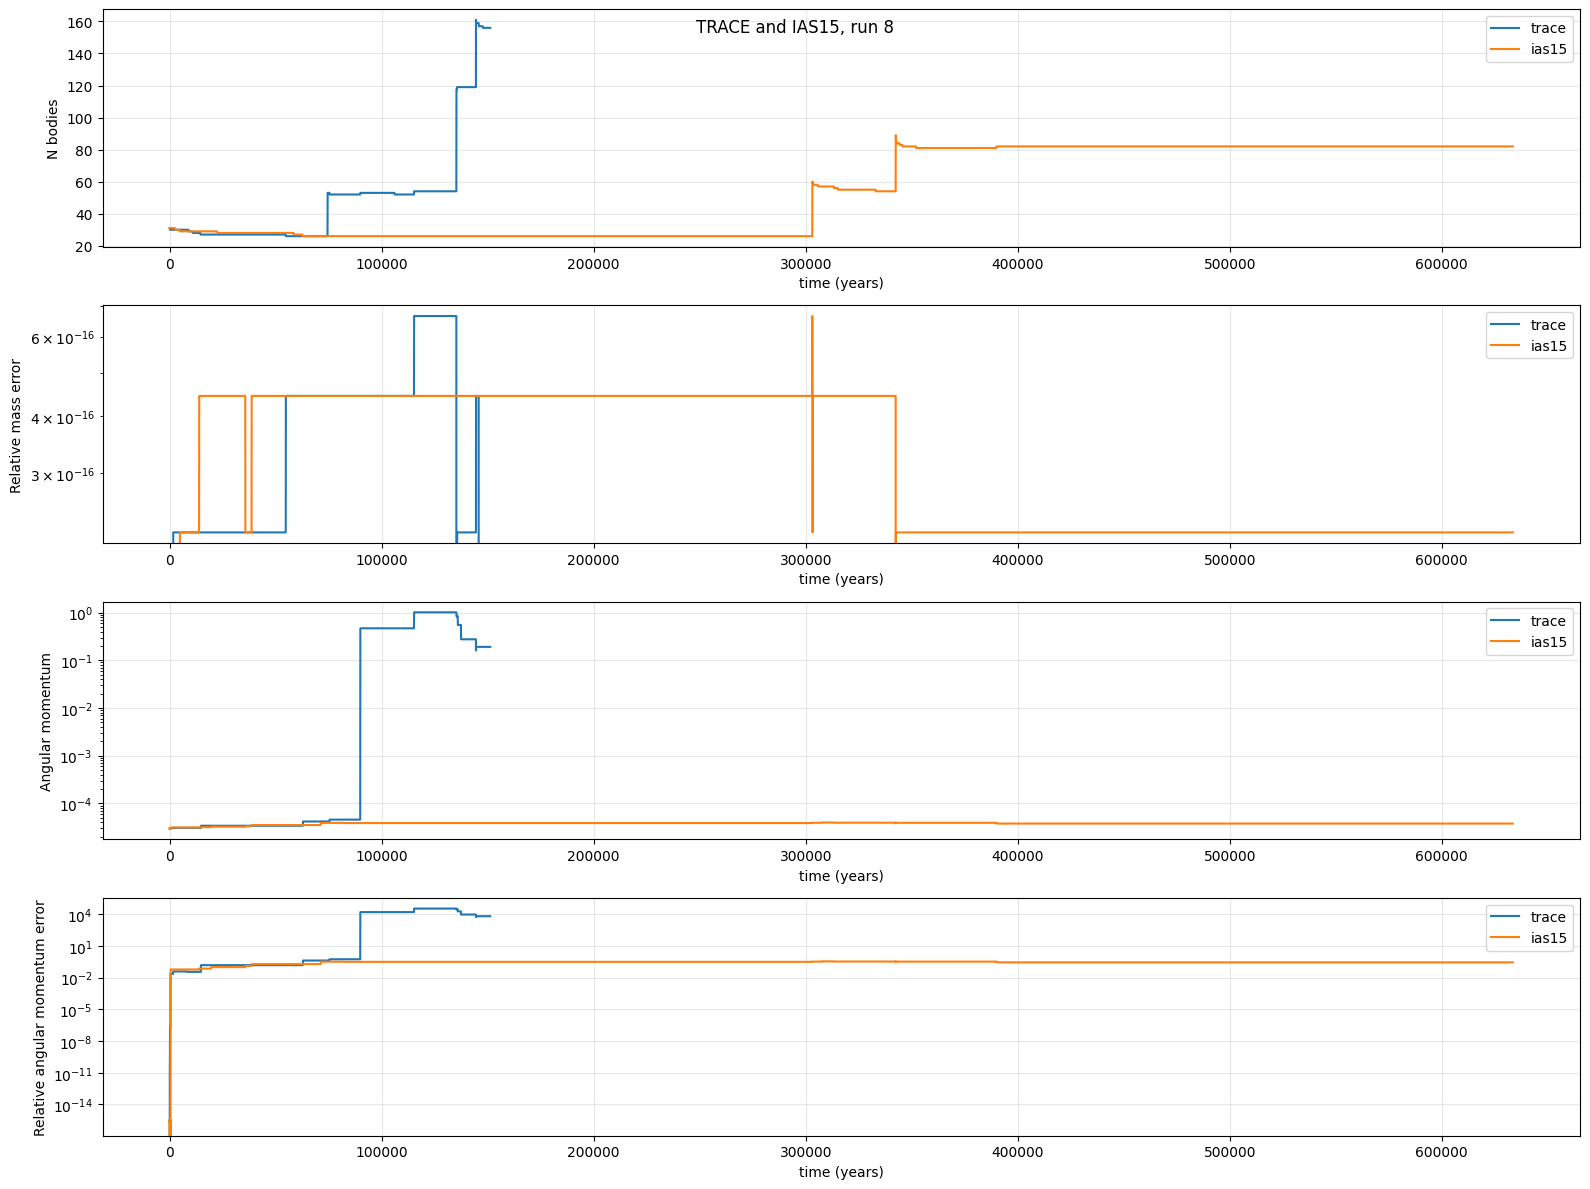

In [12]:
plt.figure(figsize=(16,12))

plt.subplot(4, 1, 1)
plt.plot(trace_times, trace_n_bodies, label = 'trace')
plt.plot(ias15_times, ias15_n_bodies, label = 'ias15')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")

plt.subplot(4, 1, 2)
plt.plot(trace_times , trace_mass_errors, label = 'trace')
plt.plot(ias15_times , ias15_mass_errors, label = 'ias15')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")
plt.yscale("log")

plt.subplot(4, 1, 3)
plt.plot(trace_times, trace_angular_momentums, label = 'trace')
plt.plot(ias15_times, ias15_angular_momentums, label = 'ias15')
plt.yscale("log")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Angular momentum")

plt.subplot(4, 1, 4)
plt.plot(trace_times , trace_L_rel_errors, label = 'trace')
plt.plot(ias15_times , ias15_L_rel_errors, label = 'ias15')
plt.yscale("log")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative angular momentum error")


plt.tight_layout()

plt.suptitle("TRACE and IAS15, run 8")

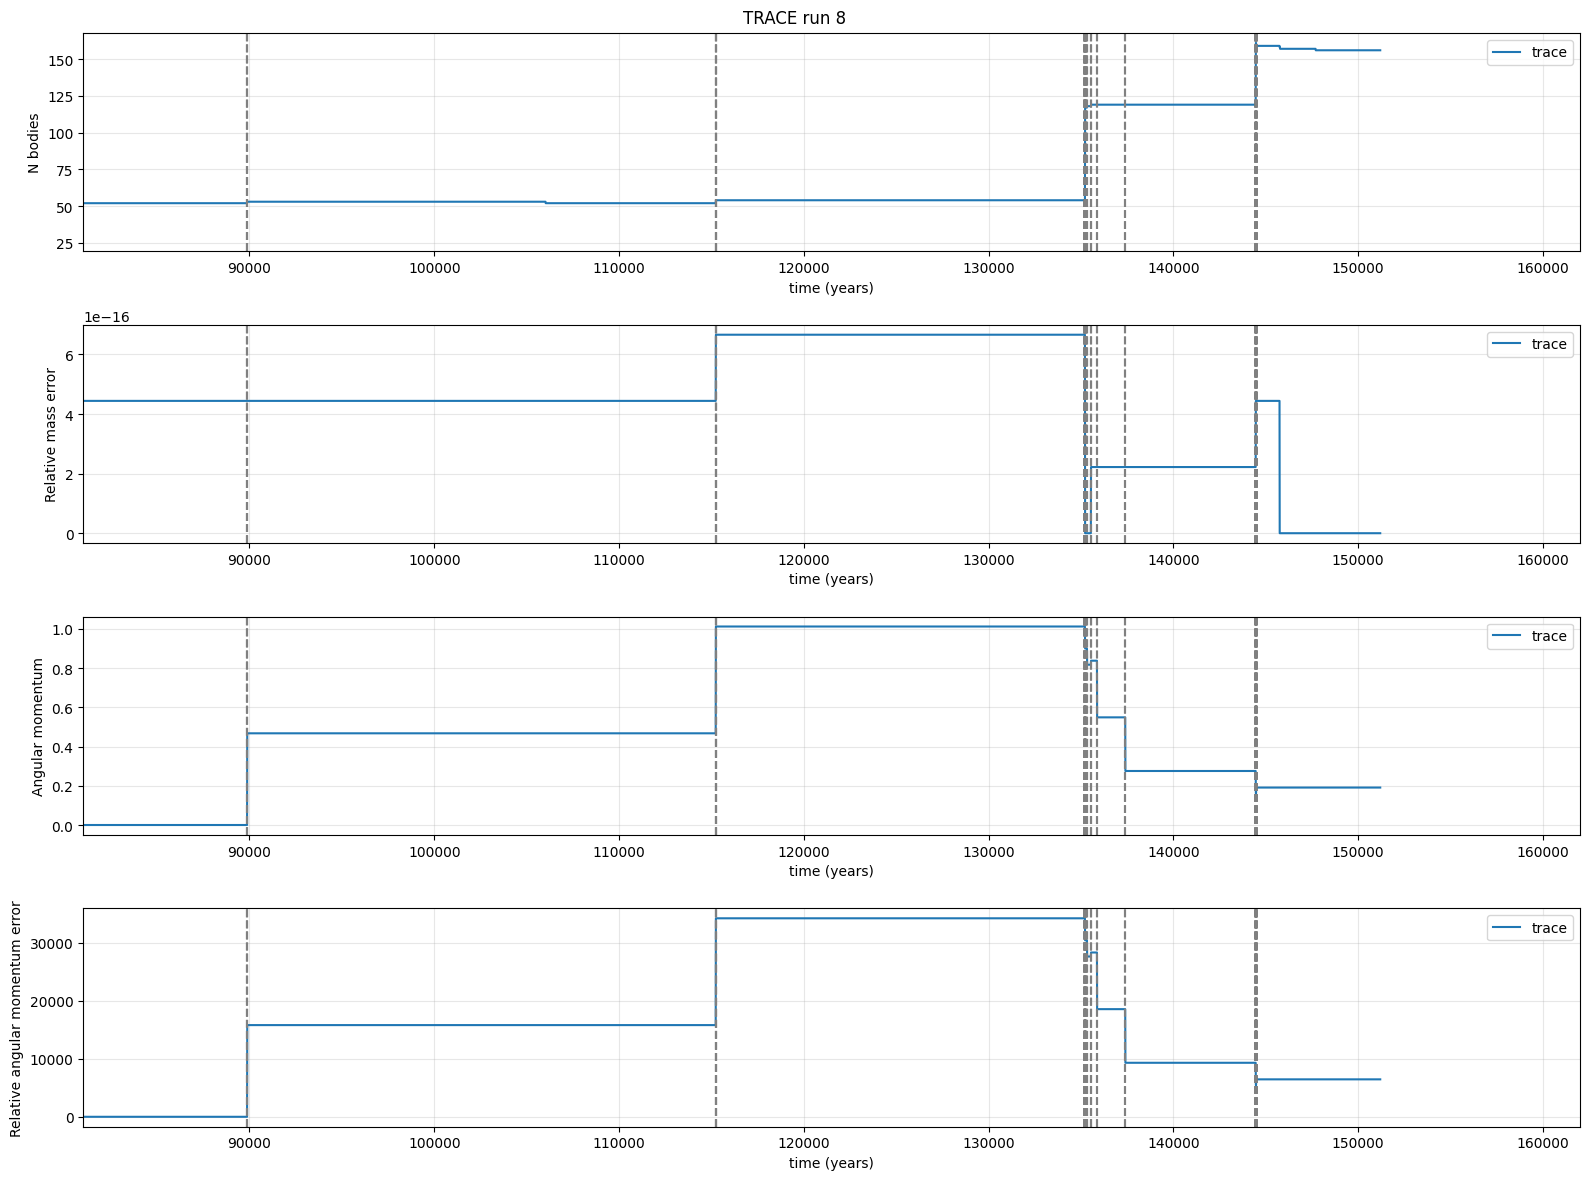

In [13]:
plt.figure(figsize=(16,12))

plt.subplot(4, 1, 1)
plt.plot(trace_times, trace_n_bodies, label = 'trace')
for i in range(len(erosive_trace)):
    plt.axvline(erosive_trace['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")
plt.xlim(0.6 * 1.35e5, 1.2 * 1.35e5)

plt.subplot(4, 1, 2)
plt.plot(trace_times , trace_mass_errors, label = 'trace')
for i in range(len(erosive_trace)):
    plt.axvline(erosive_trace['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")
plt.xlim(0.6 * 1.35e5, 1.2 * 1.35e5)

plt.subplot(4, 1, 3)
plt.plot(trace_times, trace_angular_momentums, label = 'trace')
for i in range(len(erosive_trace)):
    plt.axvline(erosive_trace['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Angular momentum")
plt.xlim(0.6 * 1.35e5, 1.2 * 1.35e5)

plt.subplot(4, 1, 4)
plt.plot(trace_times , trace_L_rel_errors, label = 'trace')
for i in range(len(erosive_trace)):
    plt.axvline(erosive_trace['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative angular momentum error")
plt.xlim(0.6 * 1.35e5, 1.2 * 1.35e5)

plt.suptitle("TRACE run 8")
plt.tight_layout()

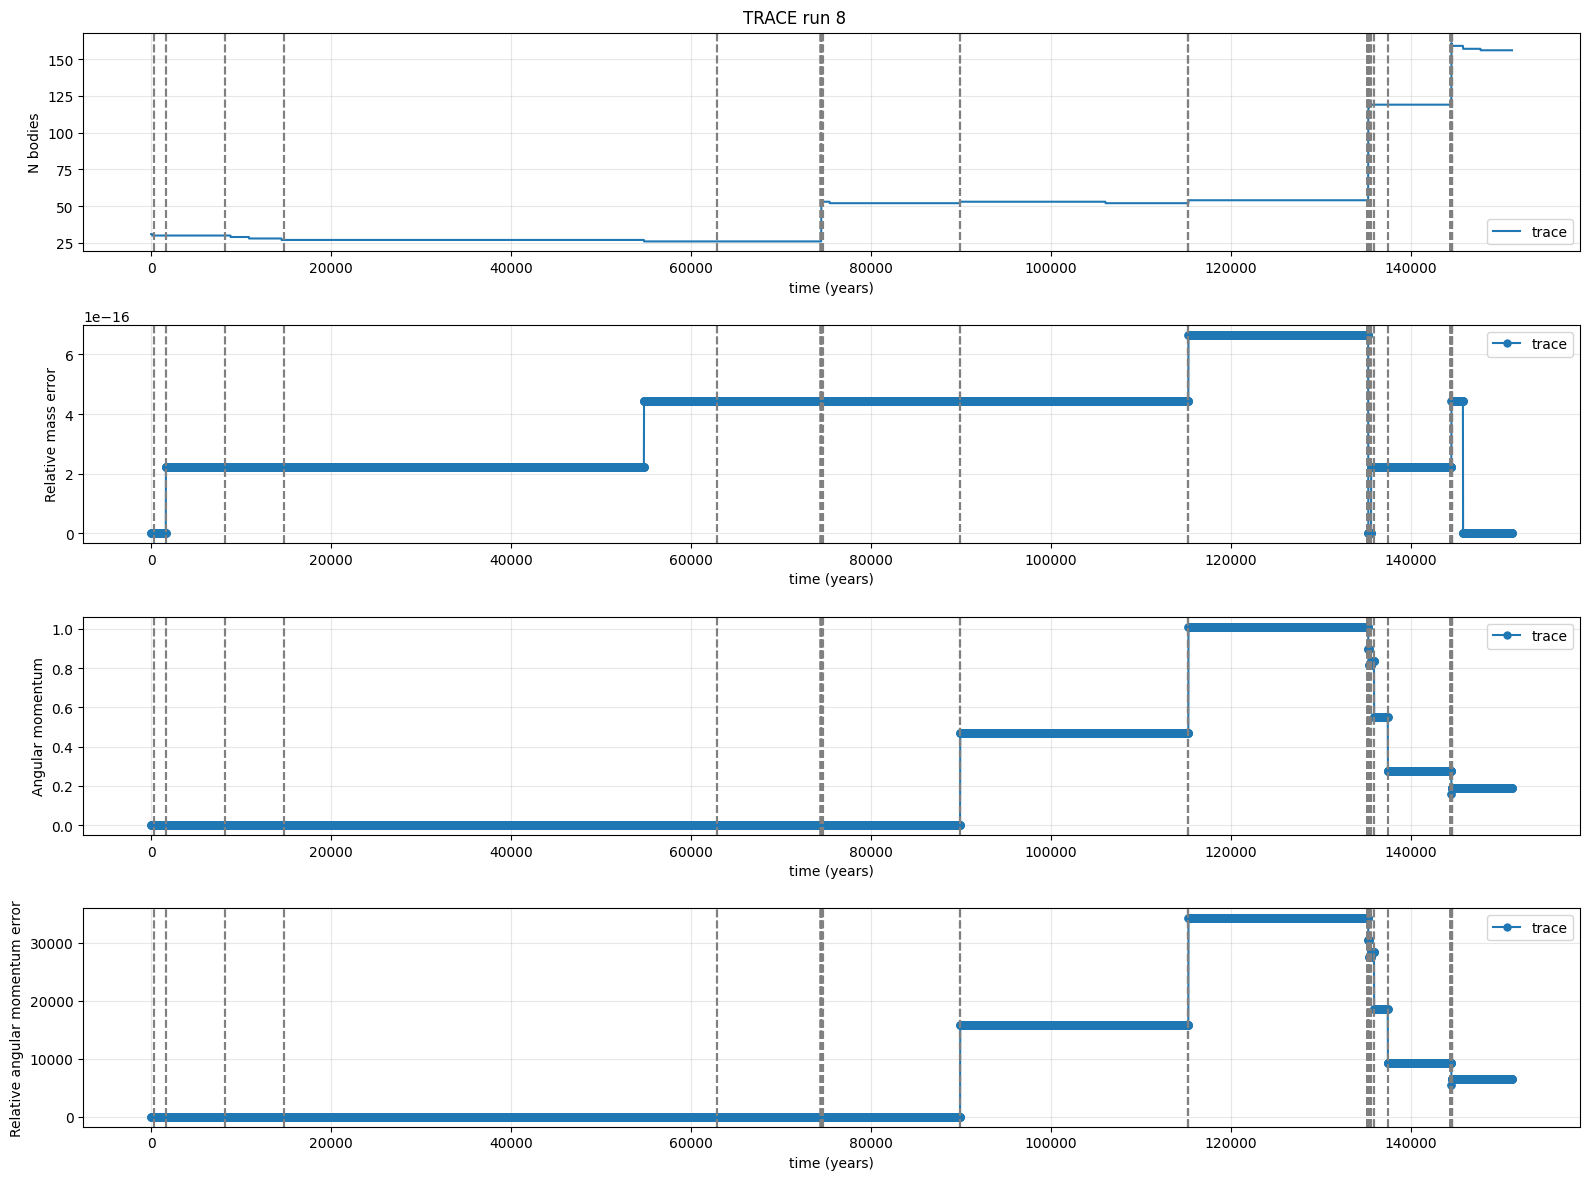

In [14]:
plt.figure(figsize=(16,12))

plt.subplot(4, 1, 1)
plt.plot(trace_times, trace_n_bodies, label = 'trace')
for i in range(len(erosive_trace)):
    plt.axvline(erosive_trace['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")

plt.subplot(4, 1, 2)
plt.plot(trace_times , trace_mass_errors, label = 'trace', marker = 'o', markersize=5)
for i in range(len(erosive_trace)):
    plt.axvline(erosive_trace['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")

plt.subplot(4, 1, 3)
plt.plot(trace_times, trace_angular_momentums, label = 'trace', marker = 'o', markersize=5)
for i in range(len(erosive_trace)):
    plt.axvline(erosive_trace['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Angular momentum")

plt.subplot(4, 1, 4)
plt.plot(trace_times , trace_L_rel_errors, label = 'trace', marker = 'o', markersize=5)
for i in range(len(erosive_trace)):
    plt.axvline(erosive_trace['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative angular momentum error")

plt.suptitle("TRACE run 8")
plt.tight_layout()

# Collisions we want to investigate:

## 1) t around 90000
## 2) t around 110000
## 3) t around 130000

In [15]:
subset_1 = erosive_trace[(erosive_trace['t'] < 10e4) & (erosive_trace['t'] > 8e4)]
subset_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
55,89878.19,5,103,16,77,2.033653e-07,3.610304e-07,1.343930e-08,0.000021,0.000026,0.000009,12.73296,0.294041
56,89878.19,5,104,16,77,6.182993e-08,3.610304e-07,1.343930e-08,0.000014,0.000026,0.000009,12.73296,0.294041
57,89878.19,5,105,16,77,1.092744e-07,3.610304e-07,1.343930e-08,0.000017,0.000026,0.000009,12.73296,0.294041


In [16]:
coll_1 = subset_1[(subset_1['parent1_id'] == 16) & ((subset_1['parent2_id'] == 77))]
coll_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
55,89878.19,5,103,16,77,2.033653e-07,3.610304e-07,1.343930e-08,0.000021,0.000026,0.000009,12.73296,0.294041
56,89878.19,5,104,16,77,6.182993e-08,3.610304e-07,1.343930e-08,0.000014,0.000026,0.000009,12.73296,0.294041
57,89878.19,5,105,16,77,1.092744e-07,3.610304e-07,1.343930e-08,0.000017,0.000026,0.000009,12.73296,0.294041


In [17]:
t1 = coll_1['t'].iloc[0]
print("t_1 = ", t1)

t_1 =  89878.19


In [18]:
subset_2 = erosive_trace[(erosive_trace['t'] < 12e4) & (erosive_trace['t'] > 10e4)]
subset_2

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
61,115233.6,5,112,22,99,8.826154e-08,2.210870e-07,9.800344e-09,0.000016,0.000022,0.000008,11.98612,0.699568
62,115233.6,5,113,22,99,4.028280e-08,2.210870e-07,9.800344e-09,0.000012,0.000022,0.000008,11.98612,0.699568
63,115233.6,5,114,22,99,5.183307e-08,2.210870e-07,9.800344e-09,0.000013,0.000022,0.000008,11.98612,0.699568
64,115233.6,5,115,22,99,5.050991e-08,2.210870e-07,9.800344e-09,0.000013,0.000022,0.000008,11.98612,0.699568


In [19]:
coll_2 = subset_2[(subset_2['parent1_id'] == 22) & ((subset_2['parent2_id'] == 99))]
coll_2

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
61,115233.6,5,112,22,99,8.826154e-08,2.210870e-07,9.800344e-09,0.000016,0.000022,0.000008,11.98612,0.699568
62,115233.6,5,113,22,99,4.028280e-08,2.210870e-07,9.800344e-09,0.000012,0.000022,0.000008,11.98612,0.699568
63,115233.6,5,114,22,99,5.183307e-08,2.210870e-07,9.800344e-09,0.000013,0.000022,0.000008,11.98612,0.699568
64,115233.6,5,115,22,99,5.050991e-08,2.210870e-07,9.800344e-09,0.000013,0.000022,0.000008,11.98612,0.699568


In [20]:
t2 = coll_2['t'].iloc[0]
print("t_2 = ", t2)

t_2 =  115233.6


In [21]:
subset_3 = erosive_trace[(erosive_trace['t'] < 14e4) & (erosive_trace['t'] > 12e4)]
subset_3

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
65,135218.6,6,117,60,61,1.400000e-08,4.133684e-07,3.434451e-07,0.000009,0.000027,0.000025,14.551020,0.443223
66,135218.6,6,118,60,61,1.045913e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.551020,0.443223
67,135218.6,6,119,60,61,1.291415e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.551020,0.443223
68,135218.6,6,120,60,61,1.060507e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.551020,0.443223
69,135218.6,6,121,60,61,1.096885e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.551020,0.443223
...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,135532.4,8,189,124,127,1.541974e-08,1.284960e-08,1.277223e-08,0.000009,0.000008,0.000008,5.702915,0.774891
136,135864.1,6,191,138,131,1.400000e-08,1.399260e-08,1.012509e-08,0.000009,0.000009,0.000008,13.892070,0.744500
137,135864.1,6,192,138,131,1.011769e-08,1.399260e-08,1.012509e-08,0.000008,0.000009,0.000008,13.892070,0.744500
138,137391.4,6,194,136,133,1.400000e-08,1.399164e-08,9.545993e-09,0.000009,0.000009,0.000008,7.184498,0.510174


In [22]:
coll_3 = subset_3[(subset_3['parent1_id'] == 60) & ((subset_3['parent2_id'] == 61))]
coll_3

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
65,135218.6,6,117,60,61,1.400000e-08,4.133684e-07,3.434451e-07,0.000009,0.000027,0.000025,14.55102,0.443223
66,135218.6,6,118,60,61,1.045913e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.55102,0.443223
67,135218.6,6,119,60,61,1.291415e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.55102,0.443223
68,135218.6,6,120,60,61,1.060507e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.55102,0.443223
69,135218.6,6,121,60,61,1.096885e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.55102,0.443223
...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,135218.6,6,177,60,61,9.428664e-09,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.55102,0.443223
126,135218.6,6,178,60,61,1.416353e-08,4.133684e-07,3.434451e-07,0.000009,0.000027,0.000025,14.55102,0.443223
127,135218.6,6,179,60,61,8.990677e-09,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.55102,0.443223
128,135218.6,6,180,60,61,1.214834e-08,4.133684e-07,3.434451e-07,0.000008,0.000027,0.000025,14.55102,0.443223


In [23]:
t3 = coll_3['t'].iloc[0]
print("t_3 = ", t3)

t_3 =  135218.6


In [24]:
print("t1 = ", t1)
tolerance = 10
trace_archive_df[(trace_archive_df['t'] < t1 + tolerance) & (trace_archive_df['t'] > t1 - tolerance)]

t1 =  89878.19


,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors
8987,89870.005478,52,1.000009,4.440852e-16,0.000046,0.546081
8988,89880.016437,53,1.000009,4.440852e-16,0.467369,15819.006970


In [25]:
snap_before_t1 = trace_archive[8987]
snap_after_t1 = trace_archive[8988]

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [26]:
print(snap_before_t1.angular_momentum())
print(snap_after_t1.angular_momentum())

<rebound.vectors.Vec3d object at 0x11e2a37a0, [9.89717432416617e-07, 1.497004383452894e-07, 4.566478909297508e-05]>
<rebound.vectors.Vec3d object at 0x11e2a37a0, [-0.005438423352845175, 0.07916504168672688, 0.4605837529164798]>


In [27]:
print("t2 = ", t2)
tolerance = 10
trace_archive_df[(trace_archive_df['t'] < t2 + tolerance) & (trace_archive_df['t'] > t2 - tolerance)]

t2 =  115233.6


,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors
11523,115230.016437,52,1.000009,4.440852e-16,0.467369,15819.008147
11524,115240.010957,54,1.000009,6.661278e-16,1.011653,34242.479113


In [28]:
print("t3_1= ", t3)
tolerance = 10
trace_archive_df[(trace_archive_df['t'] < t3 + tolerance) & (trace_archive_df['t'] > t3 - tolerance)]

t3_1=  135218.6


,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors
13521,135210.016436,54,1.000009,6.661278e-16,1.011653,34242.482227
13522,135220.010957,117,1.000009,0.000000e+00,0.899387,30442.379227


# For t1, t2, t3:

## How many fragments? What is the collision type? What is the impact velocity?

In [29]:
def get_v_esc(coll_df):
    parent1_mass = coll_df['parent1_mass'].iloc[0]
    parent2_mass = coll_df['parent2_mass'].iloc[0]

    parent1_radius = coll_df['parent1_radius'].iloc[0]
    parent2_radius = coll_df['parent2_radius'].iloc[0]

    G = trace_archive[0].G

    V_esc = np.sqrt(2 * G * (parent1_mass + parent2_mass) / (parent1_radius + parent2_radius))

    return V_esc

In [30]:
print("FOR COLLISION 1:")
n_frags = len(coll_1)
print("n_frags = ", n_frags)

print("coll_type = ", coll_1['type'].iloc[0])

print("impact velocity = ", coll_1['v_imp'].iloc[0])

print("V_esc = ", get_v_esc(coll_1))

print("V_imp/V_esc = ", coll_1['v_imp'].iloc[0]/get_v_esc(coll_1))

FOR COLLISION 1:
n_frags =  3
coll_type =  5
impact velocity =  12.73296
V_esc =  0.9278407250687789
V_imp/V_esc =  13.723217418653544


/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [31]:
print("FOR COLLISION 2:")
n_frags = len(coll_2)
print("n_frags = ", n_frags)

print("coll_type = ", coll_2['type'].iloc[0])

print("impact velocity = ", coll_2['v_imp'].iloc[0])

print("V_esc = ", get_v_esc(coll_2))

print("V_imp/V_esc = ", coll_2['v_imp'].iloc[0]/get_v_esc(coll_2))

FOR COLLISION 2:
n_frags =  4
coll_type =  5
impact velocity =  11.98612
V_esc =  0.7847440290878963
V_imp/V_esc =  15.27392315928979


In [32]:
print("FOR COLLISION 1:")
n_frags = len(coll_3)
print("n_frags = ", n_frags)

print("coll_type = ", coll_3['type'].iloc[0])

print("impact velocity = ", coll_3['v_imp'].iloc[0])

print("V_esc = ", get_v_esc(coll_3))

print("V_imp/V_esc = ", coll_3['v_imp'].iloc[0]/get_v_esc(coll_3))

FOR COLLISION 1:
n_frags =  65
coll_type =  6
impact velocity =  14.55102
V_esc =  1.0693248308140062
V_imp/V_esc =  13.607670541909394


# Why isn't IAS15 showing this?

In [33]:
erosive_ias15

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,394.7524,4,31,3,28,4.852007e-07,3.376331e-07,1.933115e-07,2.841279e-05,0.000025,0.000021,0.989036,0.312228
1,394.7524,4,32,3,28,4.574387e-08,3.376331e-07,1.933115e-07,1.293156e-05,0.000025,0.000021,0.989036,0.312228
6,13872.0300,4,41,37,19,8.749463e-07,8.586039e-07,4.543448e-08,3.458336e-05,0.000034,0.000013,3.433999,0.597146
7,13872.0300,4,42,37,19,2.909206e-08,8.586039e-07,4.543448e-08,1.112068e-05,0.000034,0.000013,3.433999,0.597146
8,19559.9900,4,44,2,30,4.917874e-07,3.111084e-07,2.571897e-07,2.854078e-05,0.000025,0.000023,1.170294,0.250165
...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,342457.6000,8,241,237,166,1.507552e-08,1.667405e-08,1.214194e-08,8.932316e-06,0.000009,0.000008,18.443460,1.024265
161,342457.6000,8,242,237,166,1.370615e-08,1.667405e-08,1.214194e-08,8.653234e-06,0.000009,0.000008,18.443460,1.024265
172,389941.3000,8,264,238,86,8.414628e-12,1.653371e-08,1.387637e-08,7.354474e-07,0.000009,0.000009,21.074050,1.466302
173,389941.3000,8,265,238,86,1.557417e-08,1.653371e-08,1.387637e-08,9.029734e-06,0.000009,0.000009,21.074050,1.466302


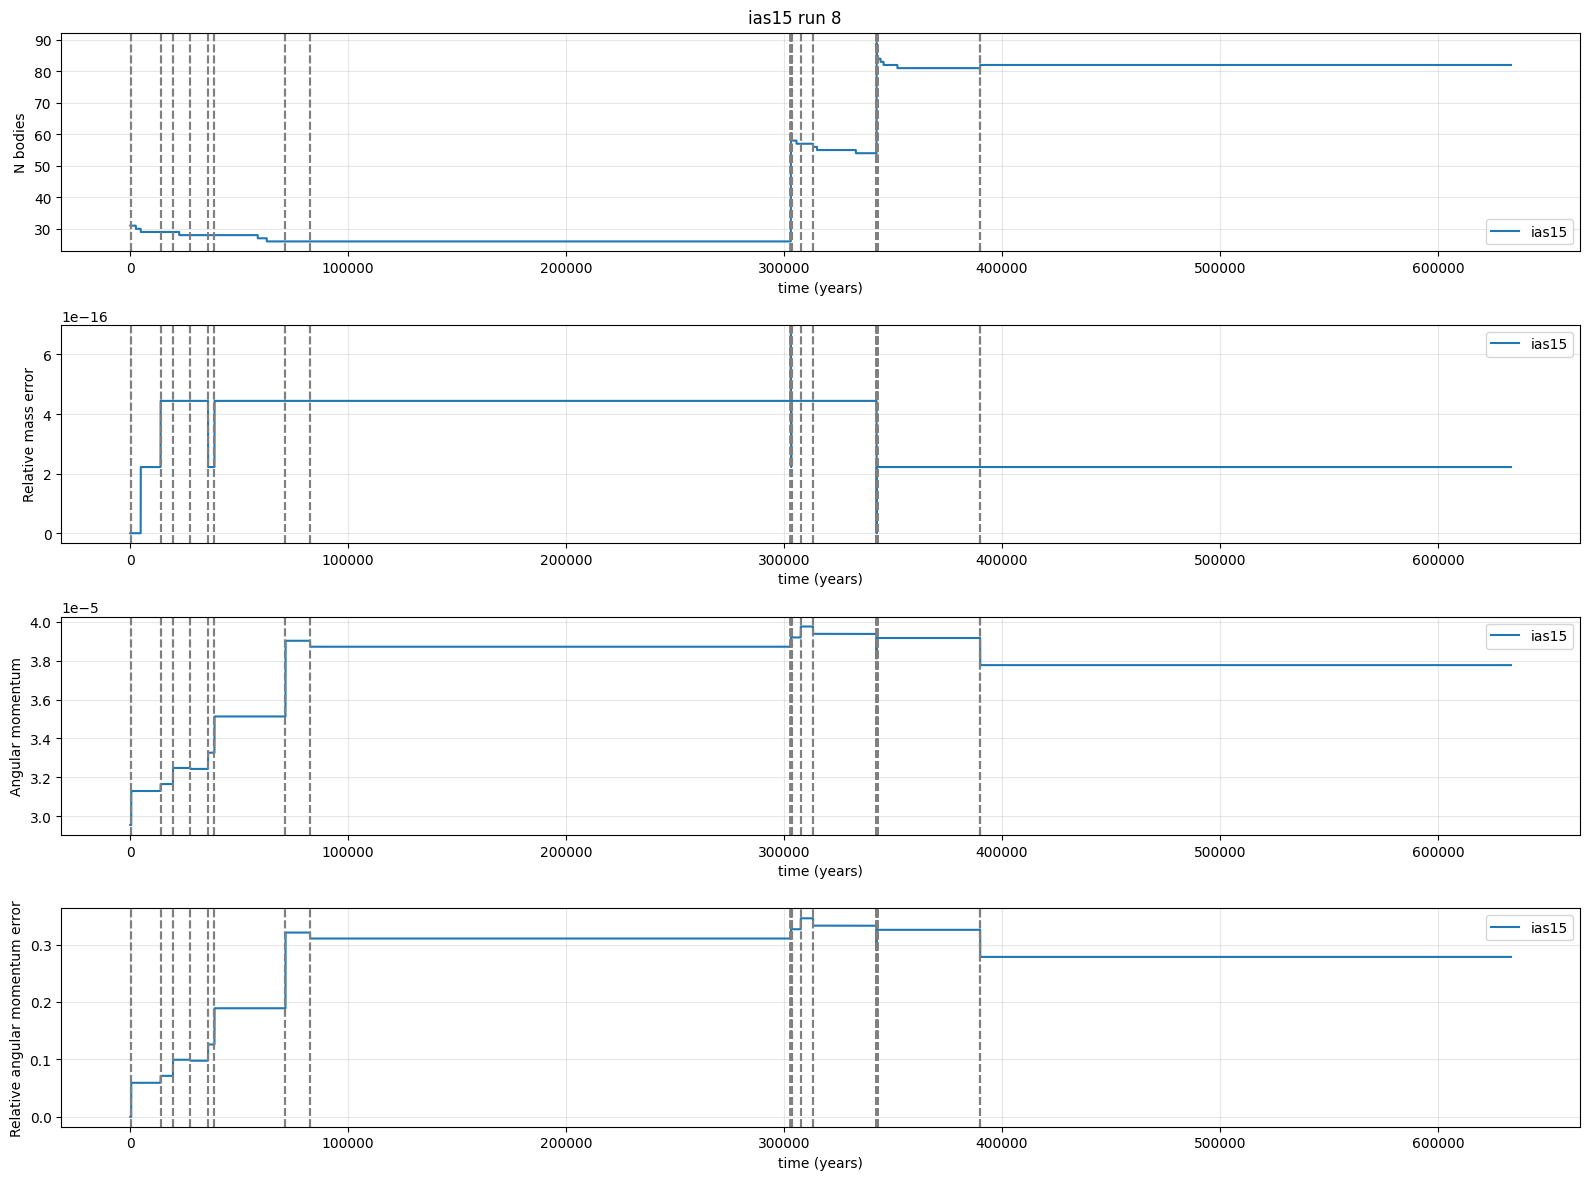

In [34]:
plt.figure(figsize=(16,12))

plt.subplot(4, 1, 1)
plt.plot(ias15_times, ias15_n_bodies, label = 'ias15')
for i in range(len(erosive_ias15)):
    plt.axvline(erosive_ias15['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("N bodies")

plt.subplot(4, 1, 2)
plt.plot(ias15_times , ias15_mass_errors, label = 'ias15')
for i in range(len(erosive_ias15)):
    plt.axvline(erosive_ias15['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative mass error")

plt.subplot(4, 1, 3)
plt.plot(ias15_times, ias15_angular_momentums, label = 'ias15')
for i in range(len(erosive_ias15)):
    plt.axvline(erosive_ias15['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Angular momentum")

plt.subplot(4, 1, 4)
plt.plot(ias15_times , ias15_L_rel_errors, label = 'ias15')
for i in range(len(erosive_ias15)):
    plt.axvline(erosive_ias15['t'].iloc[i], color = 'gray', linestyle = '--')

plt.legend()
plt.grid(True, alpha = 0.3)
plt.xlabel("time (years)")
plt.ylabel("Relative angular momentum error")

plt.suptitle("ias15 run 8")
plt.tight_layout()

(array([54.,  5., 12., 68.,  0.,  7., 46.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,
         1.,  0.,  6.,  1.]),
 array([  0.9447202 ,   5.43273286,   9.92074552,  14.40875818,
         18.89677084,  23.3847835 ,  27.87279616,  32.36080882,
         36.84882148,  41.33683414,  45.8248468 ,  50.31285946,
         54.80087212,  59.28888478,  63.77689744,  68.2649101 ,
         72.75292276,  77.24093542,  81.72894808,  86.21696074,
         90.7049734 ,  95.19298606,  99.68099872, 104.16901138,
        108.65702404, 113.1450367 , 117.63304936, 122.12106202,
        126.60907468, 131.09708734, 135.5851    ]),
 <BarContainer object of 30 artists>)

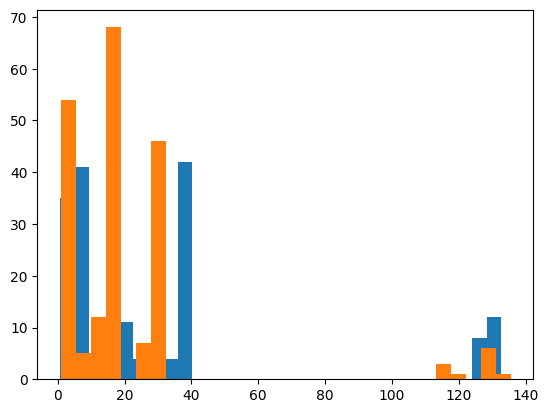

In [35]:
plt.hist(ias15_famtree['v_imp'], bins = 30)
plt.hist(trace_famtree['v_imp'], bins = 30)

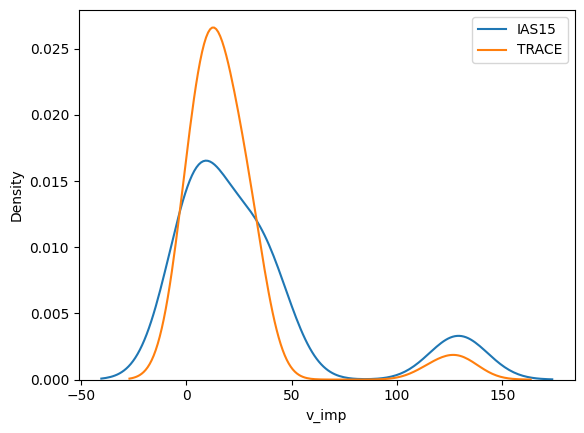

In [36]:
import seaborn as sns

# Plot the KDE for each dataset
sns.kdeplot(ias15_famtree['v_imp'], label='IAS15')
sns.kdeplot(trace_famtree['v_imp'], label='TRACE')

# Add labels and legend
plt.xlabel('v_imp')
plt.ylabel('Density')
plt.legend()

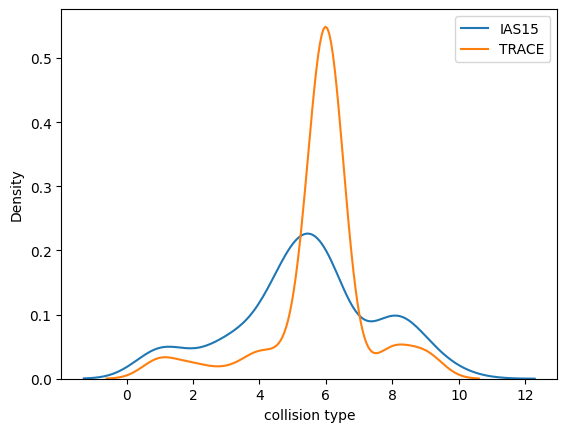

In [37]:
import seaborn as sns

# Plot the KDE for each dataset
sns.kdeplot(ias15_famtree['type'], label='IAS15')
sns.kdeplot(trace_famtree['type'], label='TRACE')

# Add labels and legend
plt.xlabel('collision type')
plt.ylabel('Density')
plt.legend()

# Close look into TRACE

In [38]:
trace_8_det_archive = rebound.Simulationarchive("../examples/embryo_trace/archive_longer_2.bin")

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: The binary file seems to be corrupted. An attempt has been made to read the uncorrupted parts of it.
  warnings.warn(message, RuntimeWarning)


In [39]:
len(trace_8_det_archive)

39262

In [49]:
t1

np.float64(89878.19)

In [63]:
snap.energy()

0.0009137945702551698

In [65]:
trace_det_times = []
trace_det_n_bodies = []
trace_det_masses = []
trace_det_mass_errors = []
trace_det_angular_momentums = []
trace_det_L_rel_errors = []
trace_det_Es = []
trace_det_E_rel_errors = []

for i in range(len(trace_8_det_archive)):
    snap = trace_8_det_archive[i]
    trace_det_times.append(snap.t)
    trace_det_n_bodies.append(snap.N)

    Lx, Ly, Lz = snap.angular_momentum()
    trace_det_angular_momentums.append(get_abs(Lx, Ly, Lz))
    trace_det_Es.append(snap.energy())

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    trace_det_masses.append(m)

for i in range(len(trace_det_masses)):
    diff = np.abs((trace_det_masses[i] - trace_det_masses[0]))
    rel_diff = diff/np.abs(trace_det_masses[0])
    trace_det_mass_errors.append(rel_diff)

for i in range(len(trace_det_angular_momentums)):
    diff = np.abs(trace_det_angular_momentums[i] - trace_det_angular_momentums[0])
    trace_det_L_rel_errors.append(diff/np.abs(trace_det_angular_momentums[0]))

for i in range(len(trace_det_Es)):
    diff = np.abs(trace_det_Es[i] - trace_det_Es[0])
    trace_det_E_rel_errors.append(diff/np.abs(trace_det_Es[0]))


trace_det_dict = {
    't': trace_det_times,
    'N_Bodies': trace_det_n_bodies,
    'total_masses': trace_det_masses,
    'm_errors': trace_det_mass_errors,
    'angular_momentums': trace_det_angular_momentums,
    'L_rel_errors': trace_det_L_rel_errors,
    'E': trace_det_Es,
    'E_rel_errors': trace_det_E_rel_errors
}

trace_det_archive_df = pd.DataFrame(trace_det_dict)

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [42]:
t1

np.float64(89878.19)

In [66]:
trace_det_archive_df = trace_det_archive_df[trace_det_archive_df['t'] < 89879]
trace_det_archive_df

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors
0,89870.005478,52,1.000009,0.0,0.000046,0.000000e+00,0.000857,0.000000e+00
1,89870.021917,52,1.000009,0.0,0.000046,1.997461e-10,0.000857,2.660931e-10
2,89870.038355,52,1.000009,0.0,0.000046,2.764475e-09,0.000857,7.481704e-09
3,89870.054793,52,1.000009,0.0,0.000046,6.181155e-10,0.000857,8.649753e-09
4,89870.071232,52,1.000009,0.0,0.000046,8.403896e-11,0.000857,1.676488e-08
...,...,...,...,...,...,...,...,...
543,89878.931506,53,1.000009,0.0,0.155962,3.413546e+03,0.000914,6.616783e-02
544,89878.947944,53,1.000009,0.0,0.155962,3.413546e+03,0.000914,6.616783e-02
545,89878.964382,53,1.000009,0.0,0.155962,3.413546e+03,0.000914,6.616783e-02
546,89878.980821,53,1.000009,0.0,0.155962,3.413546e+03,0.000914,6.616783e-02


In [67]:
close_up = trace_det_archive_df[(trace_det_archive_df['t'] < t1 + 0.2) & (trace_det_archive_df['t'] > t1 - 0.2)]
close_up

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors
486,89877.994519,52,1.000009,0.0,0.000046,1.209109e-08,0.000857,1.263248e-07
487,89878.010958,52,1.000009,0.0,0.000046,1.334896e-08,0.000857,1.247033e-07
488,89878.027396,52,1.000009,0.0,0.000046,1.398402e-08,0.000857,1.248071e-07
489,89878.043834,52,1.000009,0.0,0.000046,1.635497e-08,0.000857,1.087431e-07
490,89878.060273,52,1.000009,0.0,0.000046,1.290201e-08,0.000857,1.091918e-07
491,89878.076711,52,1.000009,0.0,0.000046,7.463208e-09,0.000857,1.038049e-07
492,89878.093149,52,1.000009,0.0,0.000046,1.077450e-08,0.000857,1.043583e-07
493,89878.109588,52,1.000009,0.0,0.000046,9.105870e-09,0.000857,1.150867e-07
494,89878.126026,52,1.000009,0.0,0.000046,1.151711e-08,0.000857,1.170588e-07
495,89878.142465,52,1.000009,0.0,0.000046,1.082869e-08,0.000857,1.243060e-07


In [57]:
coll_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
55,89878.19,5,103,16,77,2.033653e-07,3.610304e-07,1.343930e-08,0.000021,0.000026,0.000009,12.73296,0.294041
56,89878.19,5,104,16,77,6.182993e-08,3.610304e-07,1.343930e-08,0.000014,0.000026,0.000009,12.73296,0.294041
57,89878.19,5,105,16,77,1.092744e-07,3.610304e-07,1.343930e-08,0.000017,0.000026,0.000009,12.73296,0.294041


In [58]:
coll_1['parent1_mass'].iloc[0] + coll_1['parent2_mass'].iloc[0]

np.float64(3.744697e-07)

In [59]:
coll_1['new_mass'].iloc[0] + coll_1['new_mass'].iloc[1] + coll_1['new_mass'].iloc[2] 

np.float64(3.7446962999999997e-07)

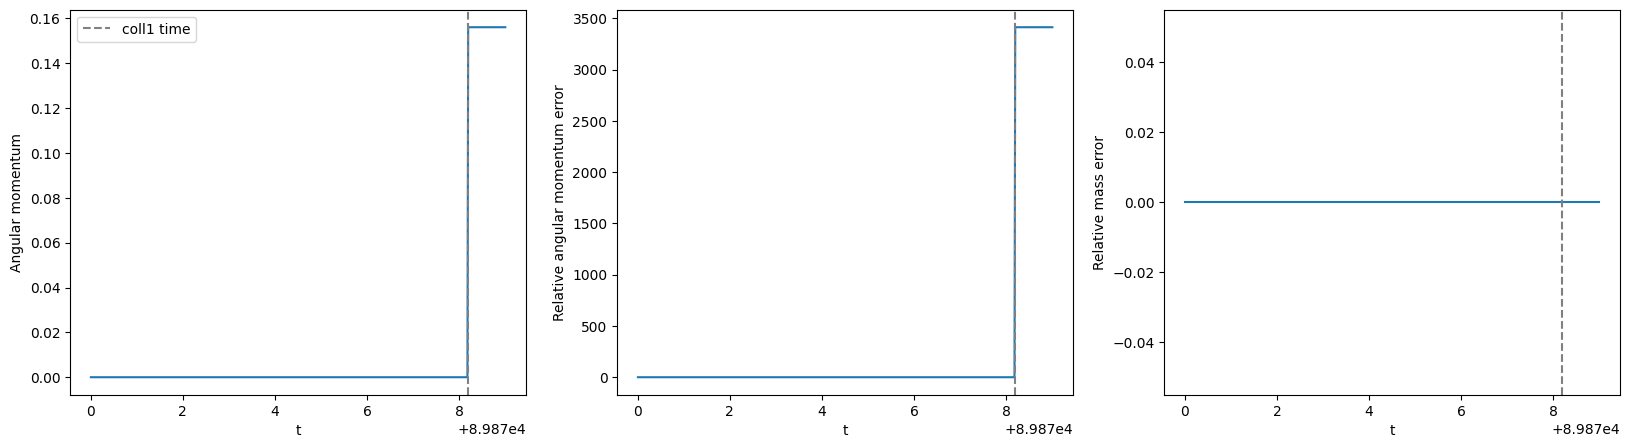

In [44]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
plt.plot(trace_det_archive_df['t'], trace_det_archive_df['angular_momentums'])
plt.xlabel('t')
plt.ylabel("Angular momentum")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')
plt.legend()

plt.subplot(1,3,2)
plt.plot(trace_det_archive_df['t'], trace_det_archive_df['L_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative angular momentum error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(1,3,3)
plt.plot(trace_det_archive_df['t'], trace_det_archive_df['m_errors'])
plt.xlabel('t')
plt.ylabel("Relative mass error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

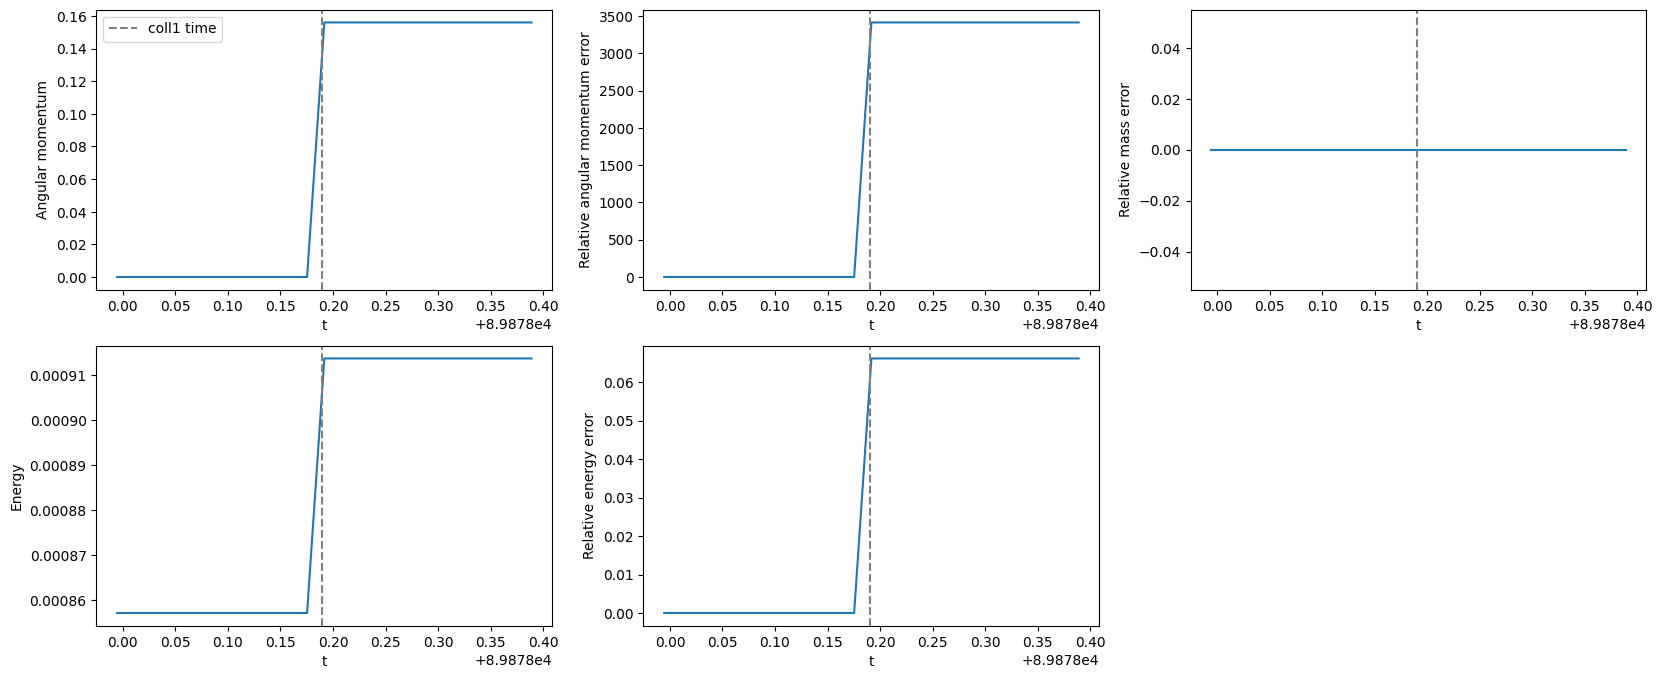

In [69]:
plt.figure(figsize=(20,8))
plt.subplot(2,3,1)
plt.plot(close_up['t'], close_up['angular_momentums'])
plt.xlabel('t')
plt.ylabel("Angular momentum")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')
plt.legend()

plt.subplot(2,3,2)
plt.plot(close_up['t'], close_up['L_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative angular momentum error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,3)
plt.plot(close_up['t'], close_up['m_errors'])
plt.xlabel('t')
plt.ylabel("Relative mass error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,4)
plt.plot(close_up['t'], close_up['E'])
plt.xlabel('t')
plt.ylabel("Energy")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,5)
plt.plot(close_up['t'], close_up['E_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative energy error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

In [45]:
heartbeat_file = pd.read_csv("../examples/embryo_trace/heartbeat_output_smaller_timestep_2.txt",
                             header = None,
                             names = ["t", "walltime", "N", "total_mass", "Lx", "Ly", "Lz", "Energy"])
famtree_detailed = pd.read_csv(
    "../examples/embryo_trace/famtree_8_detailed.csv",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

In [46]:
famtree_detailed

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,89878.19,5,52,9,31,2.033653e-07,3.610304e-07,1.343930e-08,0.000021,0.000026,0.000009,12.73296,0.294041
1,89878.19,5,53,9,31,6.182993e-08,3.610304e-07,1.343930e-08,0.000014,0.000026,0.000009,12.73296,0.294041
2,89878.19,5,54,9,31,1.092744e-07,3.610304e-07,1.343930e-08,0.000017,0.000026,0.000009,12.73296,0.294041


In [47]:
coll_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
55,89878.19,5,103,16,77,2.033653e-07,3.610304e-07,1.343930e-08,0.000021,0.000026,0.000009,12.73296,0.294041
56,89878.19,5,104,16,77,6.182993e-08,3.610304e-07,1.343930e-08,0.000014,0.000026,0.000009,12.73296,0.294041
57,89878.19,5,105,16,77,1.092744e-07,3.610304e-07,1.343930e-08,0.000017,0.000026,0.000009,12.73296,0.294041


In [48]:
heartbeat_file

,t,walltime,N,total_mass,Lx,Ly,Lz,Energy
0,89870.01,20426.278223,52,1.000009,9.897174e-07,1.497004e-07,0.000046,0.000857
1,89871.01,20427.317443,52,1.000009,9.897178e-07,1.497020e-07,0.000046,0.000857
2,89872.01,20428.361953,52,1.000009,9.897182e-07,1.497030e-07,0.000046,0.000857
3,89873.01,20429.376224,52,1.000009,9.897183e-07,1.497028e-07,0.000046,0.000857
4,89874.02,20430.404011,52,1.000009,9.897187e-07,1.497047e-07,0.000046,0.000857
...,...,...,...,...,...,...,...,...
557,90427.00,20822.644397,53,1.000009,-8.145323e-03,3.235758e-02,0.152351,0.000914
558,90428.01,20823.372128,53,1.000009,-8.145323e-03,3.235758e-02,0.152351,0.000914
559,90429.01,20824.103983,53,1.000009,-8.145323e-03,3.235758e-02,0.152351,0.000914
560,90430.01,20824.826626,53,1.000009,-8.145323e-03,3.235758e-02,0.152351,0.000914
